In [24]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "dev_ai_articles_full.sqlite"
with sqlite3.connect(DB_PATH) as conn:
    df1 = pd.read_sql_query(
        "SELECT * FROM hashnode_articles WHERE published_at IS NOT NULL",
        conn,
    )
    df2 = pd.read_sql_query(
        "SELECT * FROM articles WHERE published_at IS NOT NULL",
		conn,
	)

# turn date time string into datetime object
df1["published_at"] = pd.to_datetime(df1["published_at"])
df2["published_at"] = pd.to_datetime(df2["published_at"])

In [25]:
display(df1.head())
display(df2.head())

,id,title,url,published_at,tags,body_text
0,69c4b8a8efeaf33e6b3675be,MonALISA : A Distributed Monitoring Service Ar...,https://paperium.hashnode.dev/monalisa-a-distr...,2026-03-26 04:40:08.931000+00:00,"[""ai"", ""deeplearning"", ""computerscience"", ""mac...",Adaptive Monitoring for Large Scale Grids: a S...
1,69c4bd952d879655ece508e5,The Sweet Spot of AI Orchestration: From AWS L...,https://entangelk.hashnode.dev/the-sweet-spot-...,2026-03-26 05:01:09.070000+00:00,"[""ai"", ""architecture"", ""devops"", ""homeserver""]",The Sweet Spot of AI Orchestration: From AWS L...
2,69c4aaa5bbdb1bc33f100e25,"45 Claude Code Hooks for Code Quality, Securit...",https://wedgemethod.hashnode.dev/45-claude-cod...,2026-03-26 03:40:21.902000+00:00,"[""ai"", ""automation""]",45 Claude Code Hooks I Use to Automate Code Qu...
3,69c4a9faaed4ec64674bd0db,Claude Code Channels: Set Up a 24/7 AI Agent v...,https://wedgemethod.hashnode.dev/claude-code-c...,2026-03-26 03:37:30.754000+00:00,"[""ai"", ""automation"", ""tutorial""]",Claude Code Channels Just Dropped — Here's How...
4,69c4a88eea32df99834d3704,I Built My Own OpenClaw Alternative With Claud...,https://wedgemethod.hashnode.dev/i-built-my-ow...,2026-03-26 03:31:26.064000+00:00,"[""ai"", ""automation"", ""productivity""]",I Built My Own OpenClaw Alternative With Claud...


,id,title,url,published_at,tags,body_text
0,142249,The Distressed Code Review,https://dev.to/rfornal/the-distressed-code-rev...,2022-04-24 12:31:48+00:00,"w,e,b,d,e,v,,, ,p,r,o,d,u,c,t,i,v,i,t,y,,, ,d,...",title: The Distressed Code Review published: t...
1,198370,Avoid These Terrible Web Notifications Mistake...,https://dev.to/paco_ita/avoid-these-terrible-w...,2021-02-03 09:18:47+00:00,"p,e,r,f,o,r,m,a,n,c,e,,, ,w,e,b,d,e,v,,, ,b,e,...",This article is a brief introduction to some b...
2,385335,DNS Explained. Resolution,https://dev.to/blake/dns-explained-resolution-a2i,2021-01-24 19:54:43+00:00,"d,n,s,,, ,n,e,t,w,o,r,k,i,n,g,,, ,d,o,m,a,i,n,...",This is an article in the DNS Explained. serie...
3,423055,You don't need a library for state machines,https://dev.to/davidkpiano/you-don-t-need-a-li...,2021-01-20 23:27:30+00:00,"s,t,a,t,e,,, ,s,t,a,t,e,m,a,c,h,i,n,e,,, ,j,a,...",title: You don't need a library for state mach...
4,441453,Data Engineering Series #3: Apache Airflow - t...,https://dev.to/srinidhi/data-engineering-serie...,2021-03-30 04:00:13+00:00,"o,p,e,n,s,o,u,r,c,e,,, ,p,y,t,h,o,n,,, ,b,e,g,...",Why such attention towards Airflow ? Interest ...


In [32]:
before = len(df1)
df1 = df1[df1["published_at"] >= "2019-11-30"].copy()
print("Removed:", before - len(df1))

Removed: 0


In [33]:
# range of dates that we have developer articles for
df1["published_at"].min(), df1["published_at"].max()

(Timestamp('2020-03-24 03:41:03.311000+0000', tz='UTC'),
 Timestamp('2026-03-26 06:18:36.659000+0000', tz='UTC'))

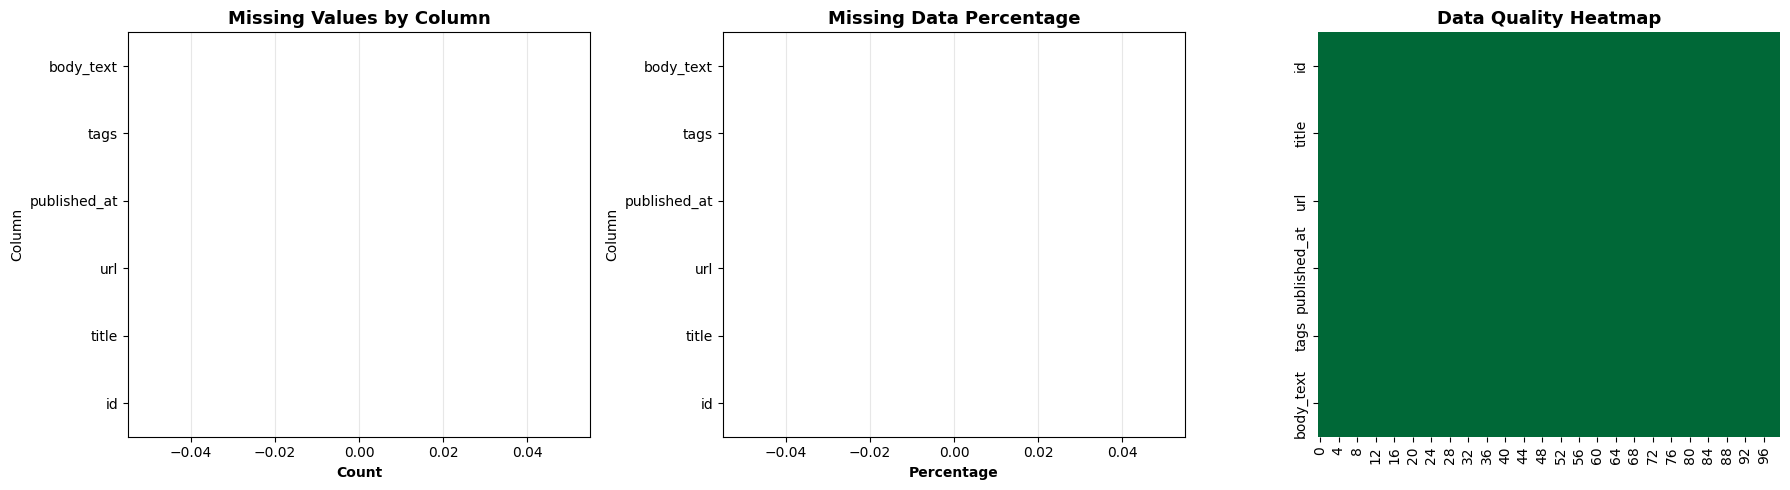

In [34]:
import seaborn as sns

# Checking the quality of the data (missing values)
missing_data = (
    df.isnull().sum().reset_index().rename(columns={"index": "Column", 0: "Missing"})
 )
missing_data["Percent"] = (missing_data["Missing"] / len(df)) * 100

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#221F1F"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
missing_data.plot(x="Column", y="Missing", kind="barh", ax=ax, color=NETFLIX_RED, legend=False)
ax.set_xlabel("Count", fontweight="bold")
ax.set_title("Missing Values by Column", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
missing_data.plot(x="Column", y="Percent", kind="barh", ax=ax, color=NETFLIX_DARK, legend=False)
ax.set_xlabel("Percentage", fontweight="bold")
ax.set_title("Missing Data Percentage", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

ax = axes[2]
sns.heatmap(df.isnull().T.iloc[:, :100], cmap="RdYlGn_r", cbar=False, ax=ax)
ax.set_title("Data Quality Heatmap", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

Notes on the data quality: It seems like there are no null or duplicated values in the database!

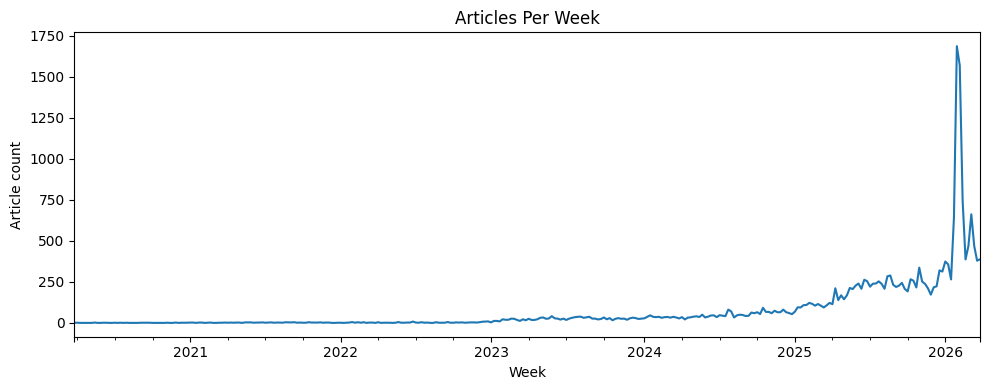

In [37]:
# Weekly posting of articles
per_week = df1.set_index("published_at").resample("W").size()
plt.figure(figsize=(10, 4))
per_week.plot()
plt.title("Articles Per Week")
plt.xlabel("Week")
plt.ylabel("Article count")
plt.tight_layout()
plt.show()

Note on posting timeline: Seems like there was a decent amount of discussion about the potential of AI between 2020-2021, and then gradually a rising discussion of AI since the release of ChatGPT at the end of 2022, which has peaked recently as AI advancements and investment ramp up.

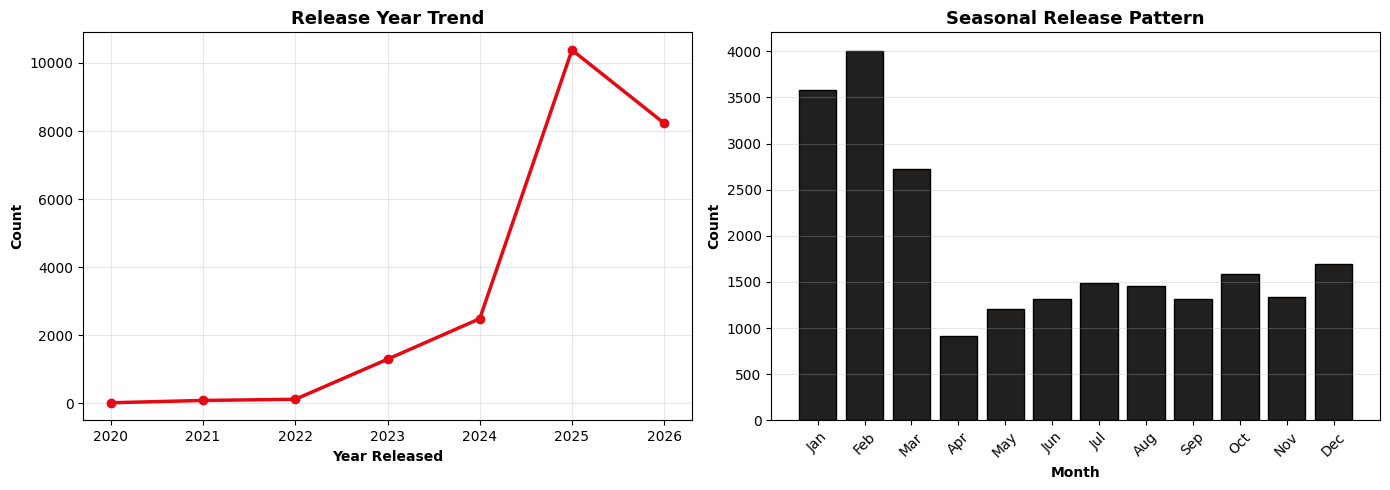

In [38]:
# Yearly and seasonal release comparison
df1["year_released"] = df1["published_at"].dt.year
df1["month_released"] = df1["published_at"].dt.month

year_counts = df1["year_released"].value_counts().sort_index()
month_counts = df1["month_released"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(year_counts.index, year_counts.values, marker="o", color=NETFLIX_RED, linewidth=2.5, markersize=6)
ax.set_xlabel("Year Released", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")
ax.set_title("Release Year Trend", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(month_counts.index, month_counts.values, color=NETFLIX_DARK, edgecolor="black")
ax.set_xlabel("Month", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")
ax.set_title("Seasonal Release Pattern", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../images/release_seasonality.png", dpi=300, bbox_inches="tight")
plt.show()

Note on posting release dates: Kind of ripped this off the example in the textbook, but nonetheless it seems like there was a lot more posts on AI gradually as we went from 2022 to 2025 (2026 has just started, but there seem to be a ton of posts already)

Seasonally, there seem to be more posts in January and December, could this be because it's holiday time and developers have more time to post articles in their free time?

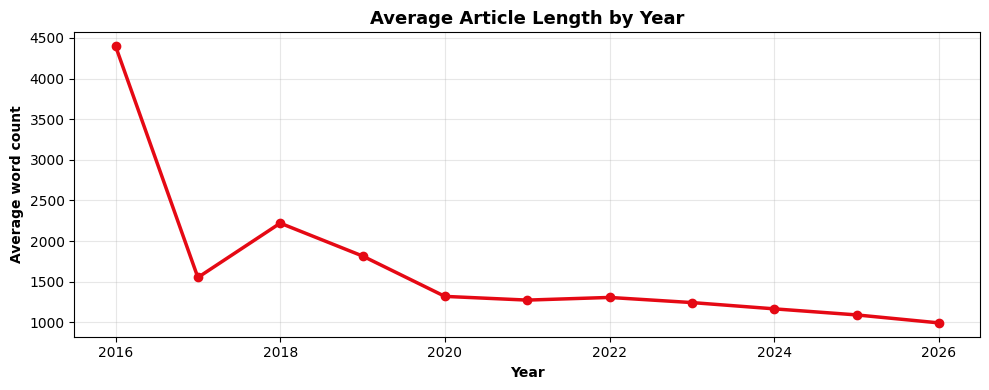

In [39]:
# Average article word count by year
with sqlite3.connect(DB_PATH) as conn:
    text_df = pd.read_sql_query(
        """
        SELECT published_at, body_text
        FROM hashnode_articles
        WHERE published_at IS NOT NULL AND body_text IS NOT NULL
        """,
        conn,
    )

text_df["published_at"] = pd.to_datetime(text_df["published_at"], utc=True, errors="coerce")
text_df = text_df.dropna(subset=["published_at"])
text_df["year_released"] = text_df["published_at"].dt.year
text_df["word_count"] = text_df["body_text"].str.split().str.len()

yearly_avg = text_df.groupby("year_released")["word_count"].mean().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(yearly_avg.index, yearly_avg.values, marker="o", color=NETFLIX_RED, linewidth=2.5, markersize=6)
plt.title("Average Article Length by Year", fontsize=13, fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Average word count", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../images/avg_length_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

count     3024.000000
mean      1453.029431
std       1070.820201
min         66.000000
10%        530.000000
25%        791.000000
50%       1187.500000
75%       1781.250000
90%       2613.700000
max      14951.000000
Name: word_count, dtype: float64
IQR: 990.2 words


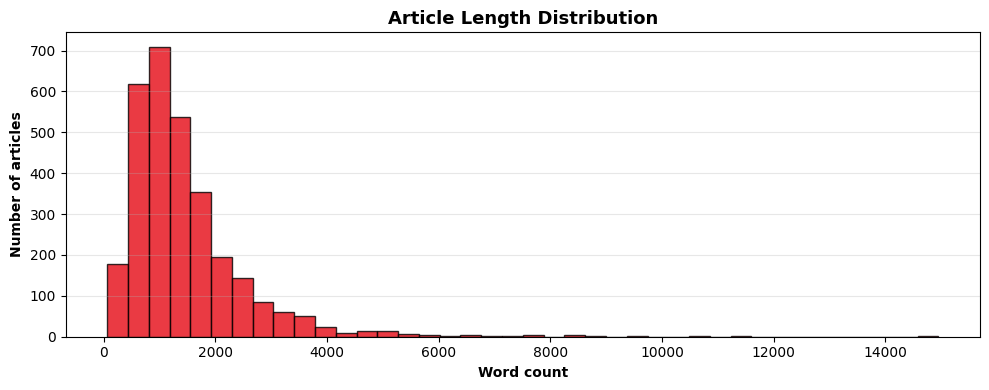

In [40]:
# Text length summary stats (word count)
with sqlite3.connect(DB_PATH) as conn:
    length_df = pd.read_sql_query(
        """
        SELECT body_text
        FROM articles
        WHERE body_text IS NOT NULL
        """,
        conn,
    )

length_df["word_count"] = length_df["body_text"].str.split().str.len()

stats = length_df["word_count"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(stats)

iqr = stats["75%"] - stats["25%"]
print(f"IQR: {iqr:.1f} words")

plt.figure(figsize=(10, 4))
plt.hist(length_df["word_count"], bins=40, color=NETFLIX_RED, edgecolor="black", alpha=0.8)
plt.title("Article Length Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Word count", fontweight="bold")
plt.ylabel("Number of articles", fontweight="bold")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../images/word_count_hist.png", dpi=300, bbox_inches="tight")
plt.show()

Note on article length: Each of these articles are extremely long on average! A significant portion of this could be due to code or some other factor inflating word counts! Definitely an **anomaly** to keep track of

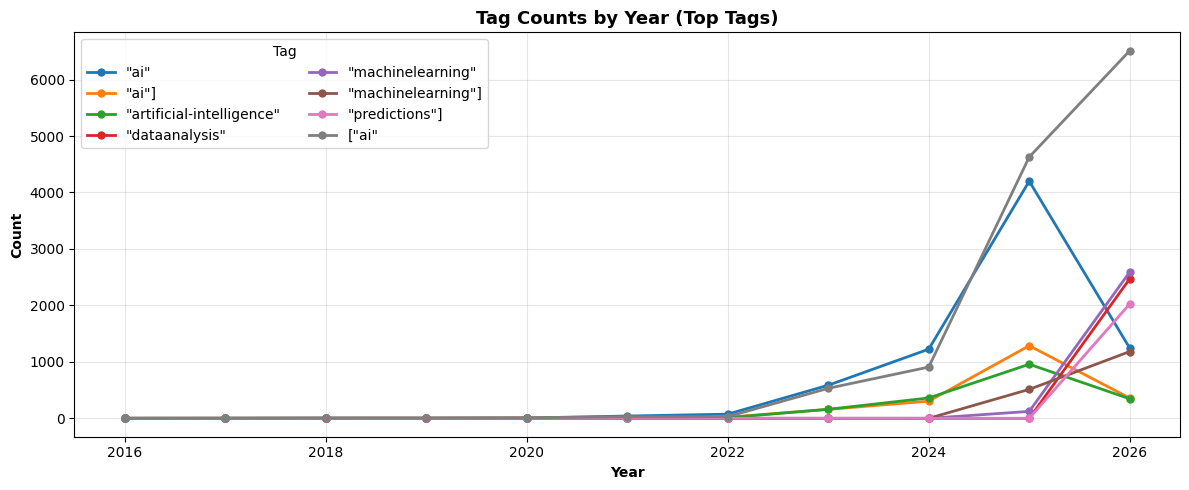

In [41]:
# Tag counts by year (top tags)
with sqlite3.connect(DB_PATH) as conn:
    tag_df = pd.read_sql_query(
        """
        SELECT published_at, tags
        FROM hashnode_articles
        WHERE published_at IS NOT NULL AND tags IS NOT NULL
        """,
        conn,
    )

tag_df["published_at"] = pd.to_datetime(tag_df["published_at"], utc=True, errors="coerce")
tag_df = tag_df.dropna(subset=["published_at"])
tag_df["year_released"] = tag_df["published_at"].dt.year

tag_df["tags"] = tag_df["tags"].str.split(",")
tag_df = tag_df.explode("tags")
tag_df["tags"] = tag_df["tags"].str.strip()
tag_df = tag_df[tag_df["tags"].ne("")]

# Pick top tags overall for a clean plot
top_tags = tag_df["tags"].value_counts().head(8).index
tag_df = tag_df[tag_df["tags"].isin(top_tags)]

tag_year_counts = (
    tag_df.groupby(["year_released", "tags"]).size().unstack(fill_value=0).sort_index()
)

plt.figure(figsize=(12, 5))
for tag in tag_year_counts.columns:
    plt.plot(
        tag_year_counts.index,
        tag_year_counts[tag],
        marker="o",
        linewidth=2.0,
        markersize=5,
        label=tag,
    )

plt.title("Tag Counts by Year (Top Tags)", fontsize=13, fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend(title="Tag", ncol=2)
plt.tight_layout()
plt.savefig("../images/tag_counts_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

We see a gradual increase in the mention of AI since the release of ChatGPT with a huge peak in 2025, something that's backed up by the above data.

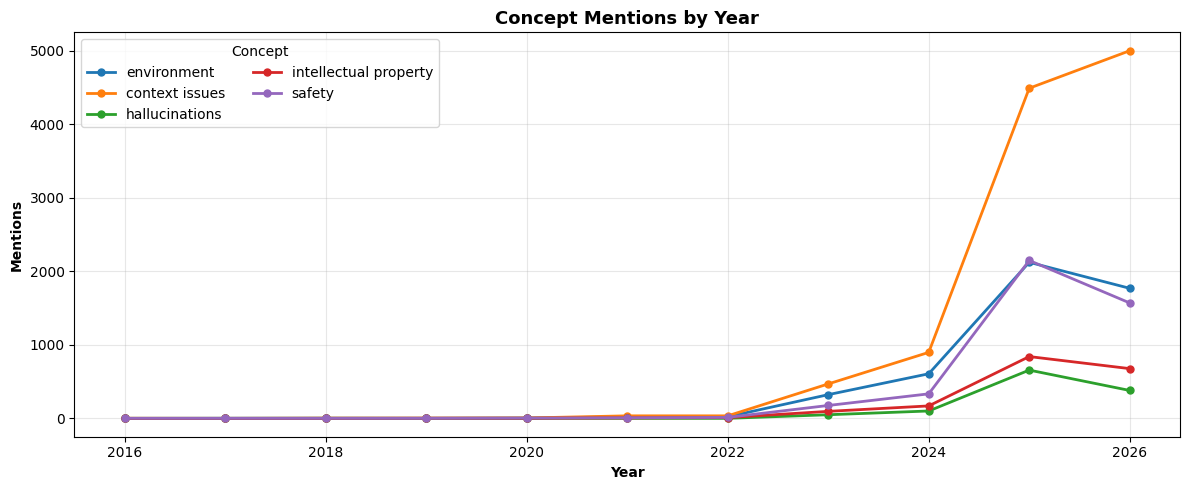

In [43]:
# Concept mentions by year (body_text)

concept_patterns = {
    "environment": r"\benvironment\b",
    "context issues": r"\bcontext\b|\bcontext issues\b|\bcontext window\b",
    "hallucinations": r"\bhallucination\b|\bhallucinations\b",
    "intellectual property": r"\bip\b|\bintellectual property\b|\bcopyright\b|\blicens\w*\b",
    "safety": r"\bsafety\b|\balignment\b|\bmisuse\b",
}

with sqlite3.connect(DB_PATH) as conn:
    concept_df = pd.read_sql_query(
        """
        SELECT published_at, body_text
        FROM hashnode_articles
        WHERE published_at IS NOT NULL AND body_text IS NOT NULL
        """,
        conn,
    )

concept_df["published_at"] = pd.to_datetime(concept_df["published_at"], utc=True, errors="coerce")
concept_df = concept_df.dropna(subset=["published_at"])
concept_df["year_released"] = concept_df["published_at"].dt.year
concept_df["body_text"] = concept_df["body_text"].str.lower()

for concept, pattern in concept_patterns.items():
    concept_df[concept] = concept_df["body_text"].str.contains(pattern, regex=True, na=False)

yearly_mentions = concept_df.groupby("year_released")[list(concept_patterns.keys())].sum().sort_index()

plt.figure(figsize=(12, 5))
for concept in yearly_mentions.columns:
    plt.plot(
        yearly_mentions.index,
        yearly_mentions[concept],
        marker="o",
        linewidth=2.0,
        markersize=5,
        label=concept,
    )

plt.title("Concept Mentions by Year", fontsize=13, fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Mentions", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend(title="Concept", ncol=2)
plt.tight_layout()
plt.savefig("../images/concept_mentions_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
# Articles where body_text mentions 'environment' in 2025
pattern = r"\benvironment\b"

with sqlite3.connect(DB_PATH) as conn:
    env_body_df = pd.read_sql_query(
        """
        SELECT published_at, title, body_text
        FROM hashnode_articles
        WHERE published_at IS NOT NULL
          AND body_text IS NOT NULL
          AND strftime('%Y', published_at) = '2025'
          AND LOWER(body_text) LIKE '%environment%'
        """,
        conn,
    )

env_body_df["published_at"] = pd.to_datetime(env_body_df["published_at"], utc=True, errors="coerce")
env_body_df["body_text"] = env_body_df["body_text"].str.lower()

env_body_df = env_body_df[
    env_body_df["body_text"].str.contains(pattern, regex=True, na=False)
].sort_values("published_at")

display(env_body_df[["published_at", "title", "body_text"]].head(10))
print(f"Total matches in 2025: {len(env_body_df)}")

,published_at,title,body_text
3529,2025-01-01 17:00:10.714000+00:00,What Are AI Sidekicks? Get the Facts,artificial intelligence (ai) sidekicks are bec...
3531,2025-01-02 00:23:31.950000+00:00,🍃 2024: Building a Foundation for Open Source AI,🌎 lilypad in 2024 with 2024 now in the rearvie...
3533,2025-01-02 04:06:27.182000+00:00,Revealing the Secrets of Llama 3.3 Multilingua...,key highlights llama 3.3 70b excels in multili...
3528,2025-01-03 11:58:49.226000+00:00,React + AI Stack for 2025,"react's been around for a while now, and it's ..."
3527,2025-01-03 13:55:31.532000+00:00,What Sets Generative AI Apart from Machine Lea...,in the ever evolving landscape of artificial i...
3526,2025-01-03 14:11:22.434000+00:00,Architectural Innovation with Midjourney,"written by pranav, on 2024 02 07 introduction:..."
3524,2025-01-03 18:59:37.149000+00:00,How I taught an AI to use a computer,an open source computer use agent i made this!...
3520,2025-01-03 21:50:30.175000+00:00,Building an Advanced AI Assistant for QAPilot:...,introduction this comprehensive guide details ...
3525,2025-01-04 00:00:00+00:00,✍️ Cross-Posting Astro Blog Posts to BlueSky U...,the problem as i've added content to my websit...
3523,2025-01-04 08:43:53.732000+00:00,What are AI Agents?,you might have already seen satya nadella’s cl...


Total matches in 2025: 2122


This is an interesting anomaly. It seems like a decent number of articles that contain the word 'environment' don't necessarily discuss AI's impact on the environment, but might instead be discussing the developer environment. This might mean that we need to filter the data further using vector embeddings and semantic searching so that we can gauge deeper context, something that initial keyword matching couldn't solve.

Or we might need to find less ambiguous terms to search.